# House Price Prediction using Machine Learning


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/House_Prediction.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.shape

(4600, 18)

In [5]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [6]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [9]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

In [12]:
df.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


# Data Visualizations   


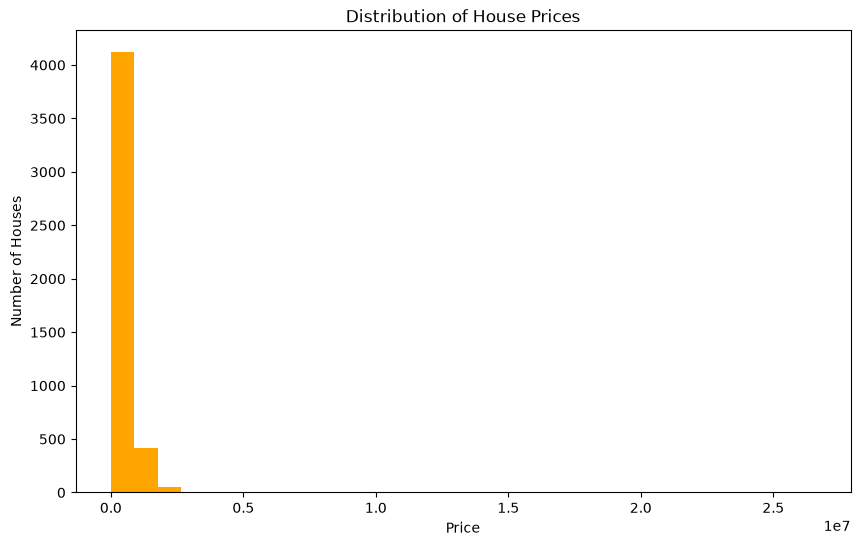

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df["price"], bins=30,color="orange")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

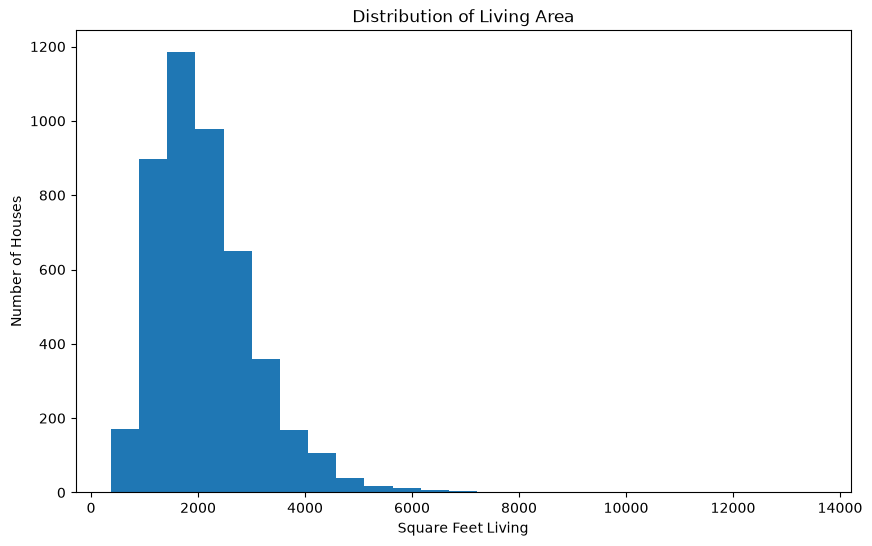

In [14]:
plt.figure(figsize=(10,6))

plt.hist(df["sqft_living"], bins=25)
plt.title("Distribution of Living Area")
plt.xlabel("Square Feet Living")
plt.ylabel("Number of Houses")

plt.show()

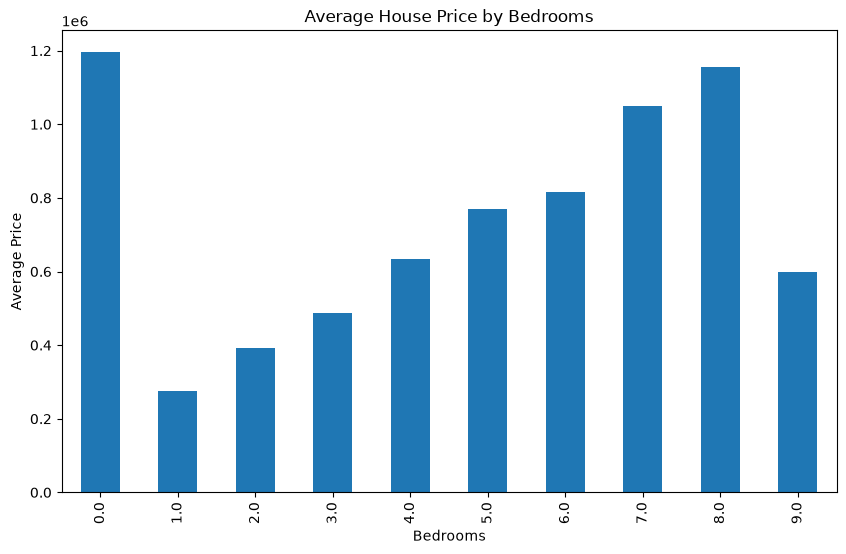

In [14]:
plt.figure(figsize=(10,6))

average_price = df.groupby("bedrooms")["price"].mean()
average_price.plot(kind="bar")
plt.title("Average House Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.show()

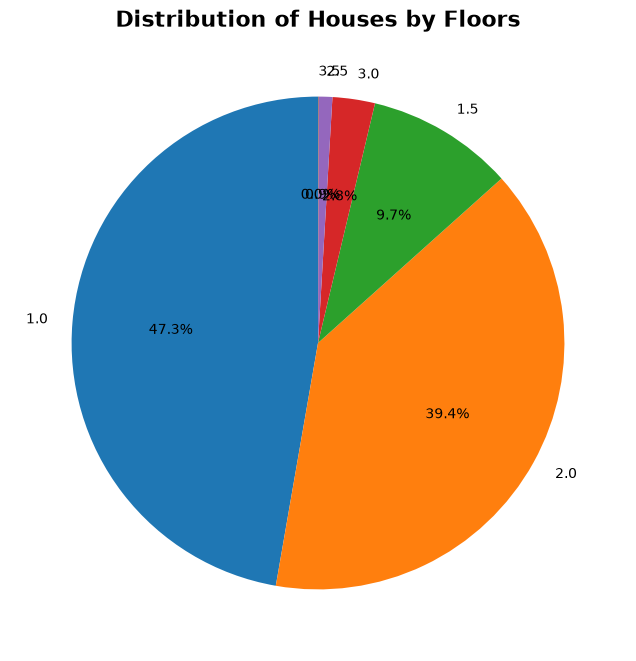

In [15]:
floor_count = df["floors"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    floor_count,
    labels=floor_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Houses by Floors", fontsize=16, fontweight="bold")

plt.show()

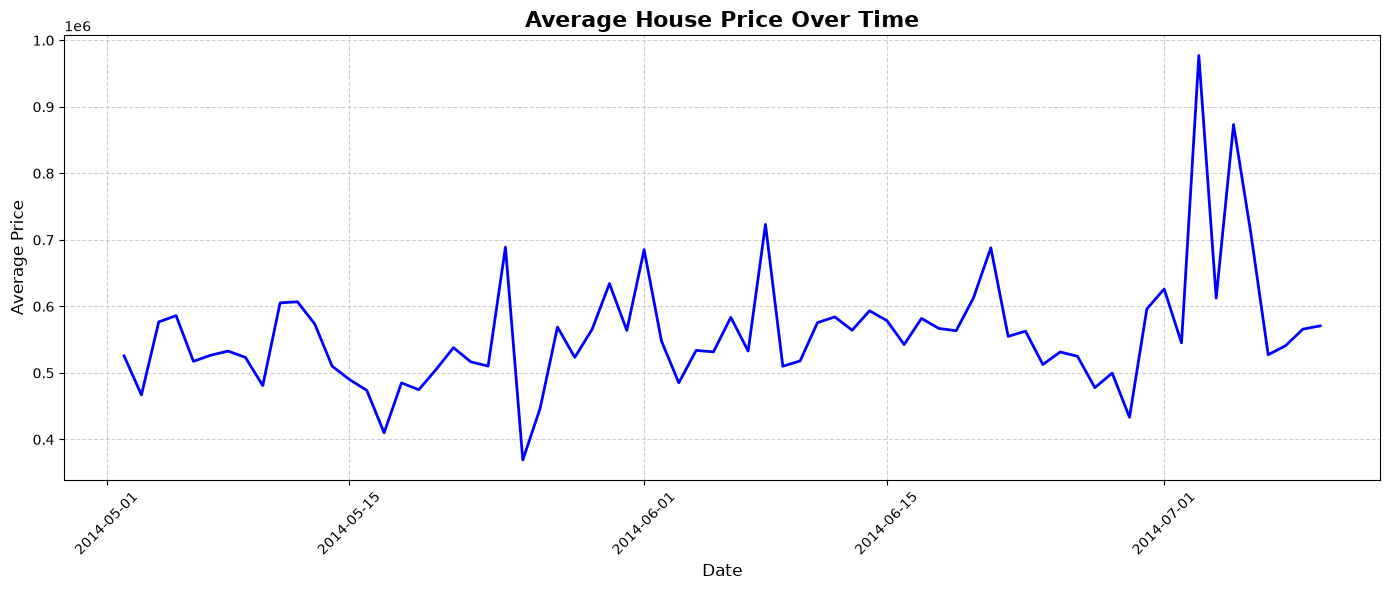

In [16]:
df["date"] = pd.to_datetime(df["date"])

average_price = df.groupby("date")["price"].mean()
plt.figure(figsize=(14,6))
plt.plot(
    average_price.index,
    average_price.values,
    color="blue",
    linewidth=2
)
plt.title("Average House Price Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

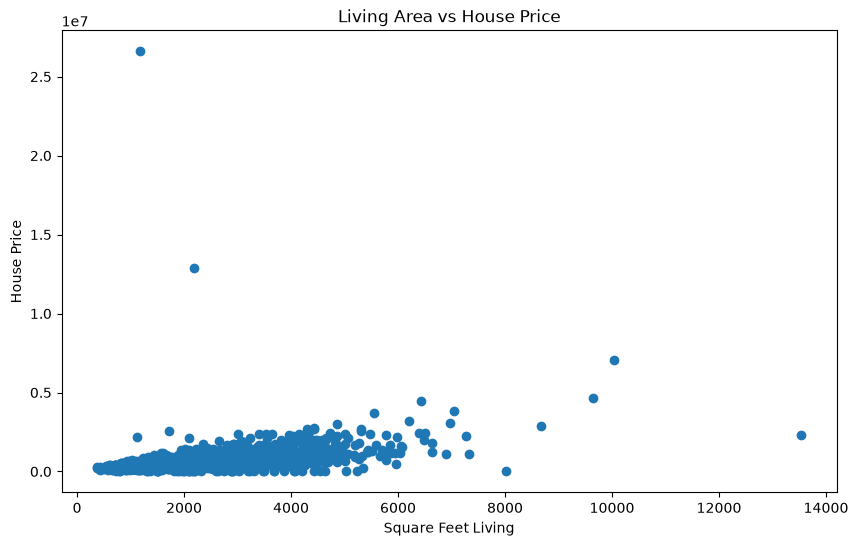

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(df["sqft_living"], df["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Square Feet Living")
plt.ylabel("House Price")

plt.show()

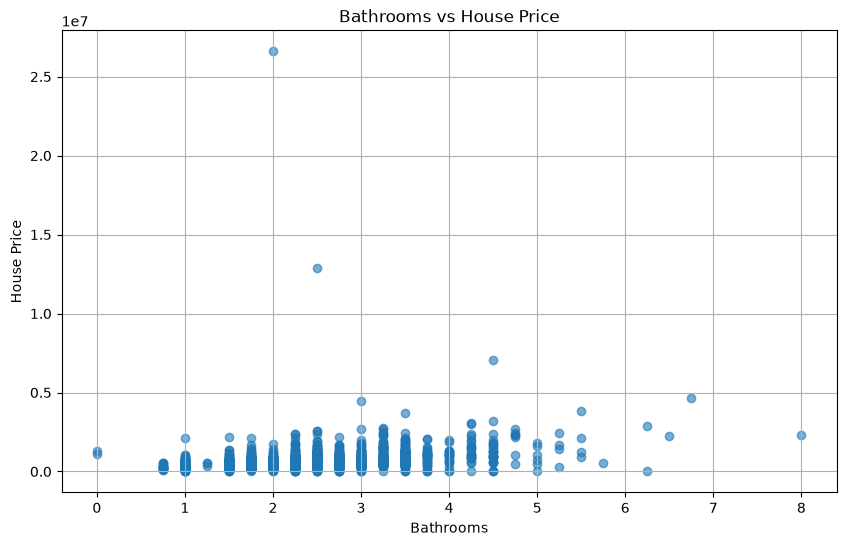

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(df["bathrooms"], df["price"], alpha=0.6)

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("House Price")

plt.grid(True)
plt.show()

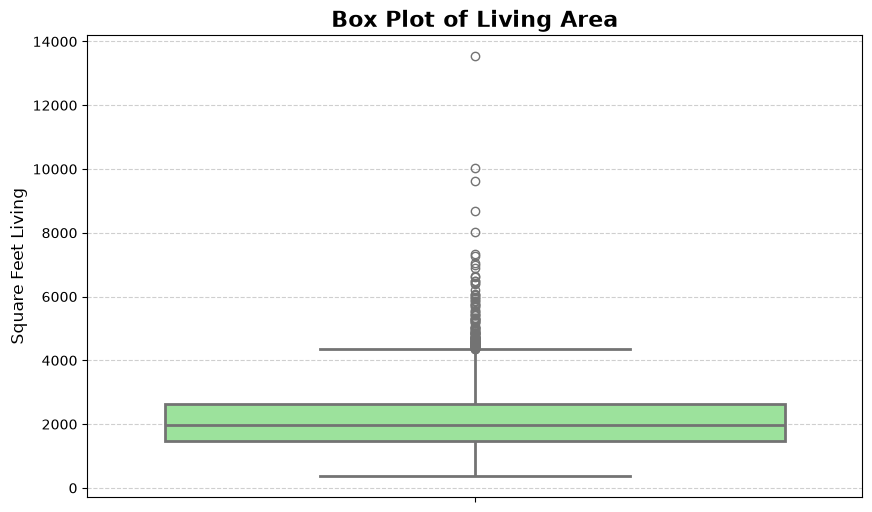

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df["sqft_living"],
    color="lightgreen",
    linewidth=2
)

plt.title("Box Plot of Living Area", fontsize=16, fontweight="bold")
plt.ylabel("Square Feet Living", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

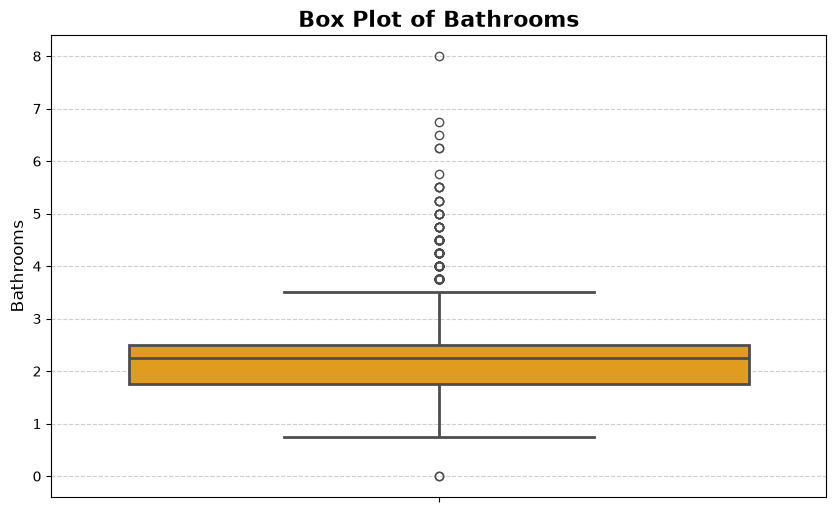

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df["bathrooms"],
    color="orange",
    linewidth=2
)

plt.title("Box Plot of Bathrooms", fontsize=16, fontweight="bold")
plt.ylabel("Bathrooms", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

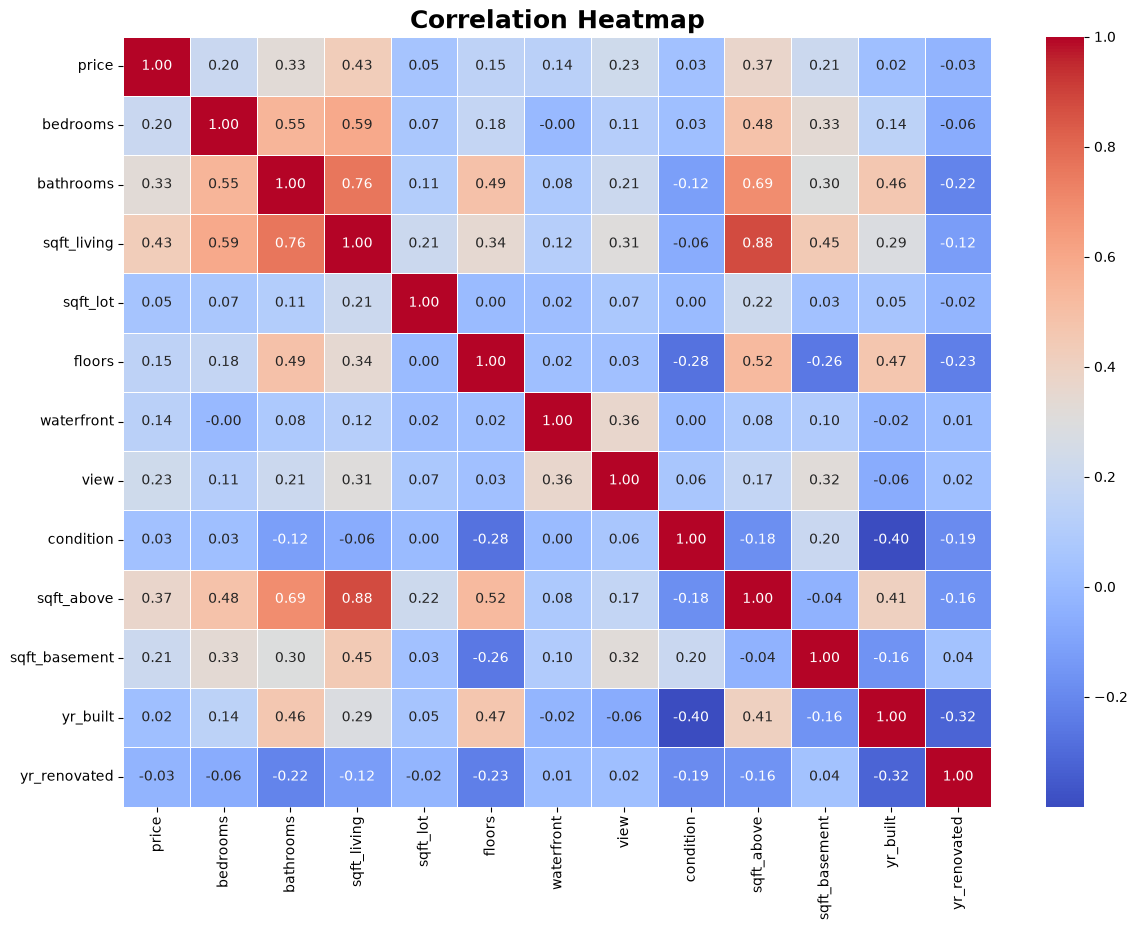

In [21]:
plt.figure(figsize=(14,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")

plt.show()

## Feature Engineering

### Total sqft

In [22]:
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]

In [23]:
print(df[["sqft_above",
          "sqft_basement",
          "total_sqft"]].head())

   sqft_above  sqft_basement  total_sqft
0        1340              0        1340
1        3370            280        3650
2        1930              0        1930
3        1000           1000        2000
4        1140            800        1940


In [24]:
print(df[["total_sqft", "price"]].corr())

            total_sqft    price
total_sqft     1.00000  0.43041
price          0.43041  1.00000


### Total Rooms

In [25]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [26]:
print(df[["total_rooms", "price"]].corr())

             total_rooms     price
total_rooms     1.000000  0.294401
price           0.294401  1.000000


## Remove Houses with Price = 0

In [27]:
df = df[df["price"] > 0]

### Feature Selection

In [28]:
X = df.drop(columns=["date", "price", "street", "country"])
y = df["price"]

### Handling Categorical Data

In [29]:
print(X.dtypes)

bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
city                 str
statezip             str
total_sqft         int64
total_rooms      float64
dtype: object


In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,...,False,False,False,False,False,False,False,False,False,False
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,...,False,False,False,False,False,False,False,False,False,False
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,...,False,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,...,False,False,False,False,False,False,False,False,False,False


In [32]:
print("Shape after encoding:", X.shape)

Shape after encoding: (4551, 133)


## Train-Test-Split

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3640, 133)
X_test : (911, 133)
y_train: (3640,)
y_test : (911,)


# Linear Regression

### Create model

In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Train the model

In [35]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [36]:
pd.options.display.float_format = '{:,.2f}'.format

### Prediction

In [37]:
predictions = model.predict(X_test)

predictions_df = pd.DataFrame(predictions, columns=["Predicted Price"])
print(predictions_df.head(10))

   Predicted Price
0     1,309,065.08
1       564,051.73
2       588,668.68
3       217,499.33
4       647,592.65
5       395,050.73
6       305,456.91
7       281,581.02
8       439,017.45
9       849,379.87


In [38]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)


,Actual Price,Predicted Price
0,"1,225,000.00","1,309,065.08"
1,"496,752.00","564,051.73"
2,"612,500.00","588,668.68"
3,"265,000.00","217,499.33"
4,"615,000.00","647,592.65"
5,"432,000.00","395,050.73"
6,"305,000.00","305,456.91"
7,"405,000.00","281,581.02"
8,"349,000.00","439,017.45"
9,"839,000.00","849,379.87"


### Model Evaluation

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [40]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 119164.57451621185
Mean Squared Error (MSE): 45411833072.39725
Root Mean Squared Error (RMSE): 213100.52339775529
R² Score: 0.6947522093468171


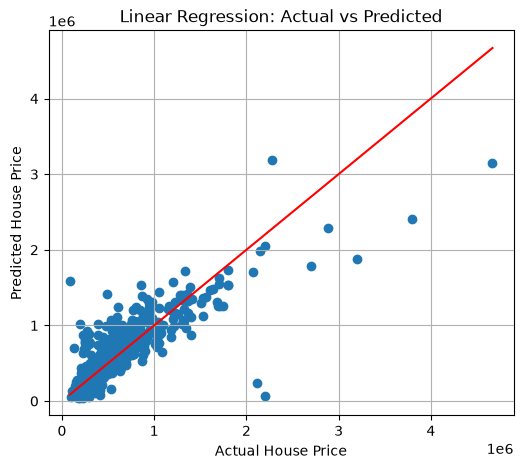

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

In [42]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.head(10)

,Feature,Coefficient
0,bedrooms,"-32,085.87"
1,bathrooms,"33,434.01"
2,sqft_living,75.88
3,sqft_lot,0.16
4,floors,"-80,247.27"
5,waterfront,"577,664.44"
6,view,"60,103.71"
7,condition,"36,819.87"
8,sqft_above,104.08
9,sqft_basement,-28.20


# Decision Tree 

In [43]:
from sklearn.tree import DecisionTreeRegressor

### Create Model

In [44]:
dt_model = DecisionTreeRegressor(random_state=42)

### Train the model

In [45]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### Predict

In [46]:
dt_predictions = dt_model.predict(X_test)

### Evaluate

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE : 178862.02420049068
MSE : 857324893730.5471
RMSE: 925918.4055469182
R² Score: -4.762738739614801


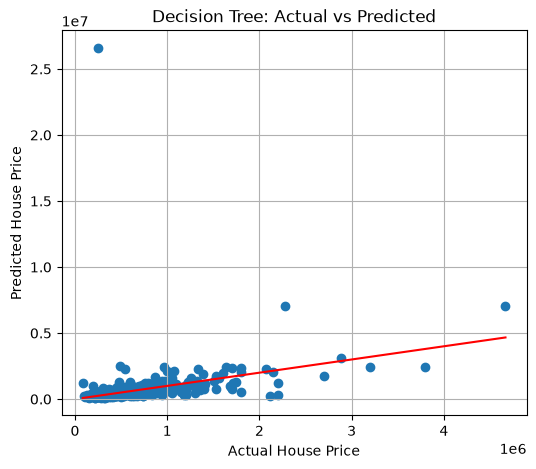

In [48]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, dt_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Random Forest

In [49]:
from sklearn.ensemble import RandomForestRegressor

### Create Model

In [50]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### Train the model

In [51]:
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Predict

In [52]:
rf_predictions = rf_model.predict(X_test)

### Evaluate

In [53]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 131445.33274839382
MSE : 312063299760.60126
RMSE: 558626.2612521912
R² Score: -1.097616994319603


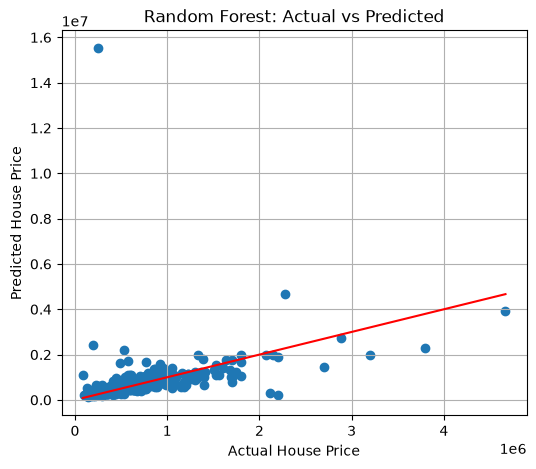

In [54]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

### Feature Importance

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,sqft_living,0.25
12,total_sqft,0.21
10,yr_built,0.12
8,sqft_above,0.09
3,sqft_lot,0.08
1,bathrooms,0.05
13,total_rooms,0.03
130,statezip_WA 98199,0.02
59,statezip_WA 98004,0.01
75,statezip_WA 98031,0.01


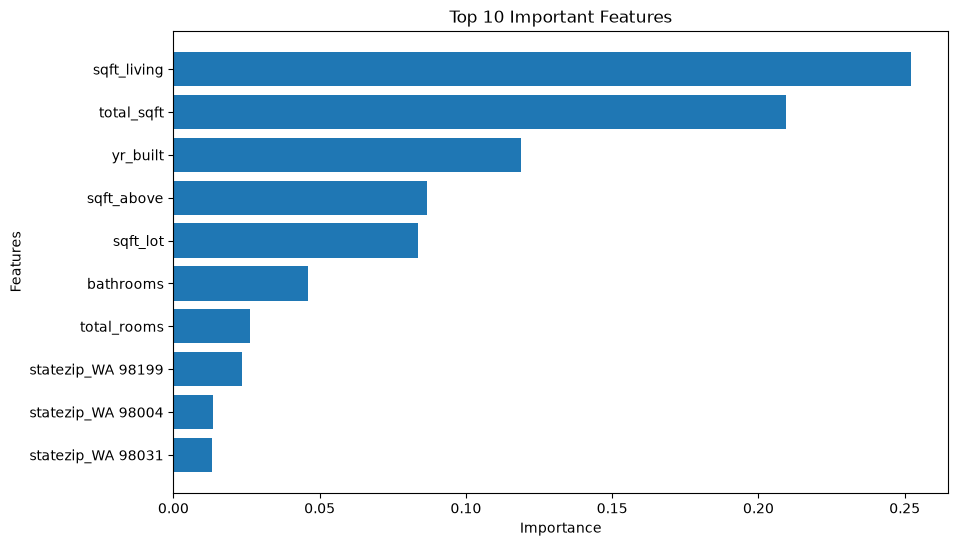

In [56]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# KNN

In [57]:
from sklearn.neighbors import KNeighborsRegressor

### Create Model

In [58]:
knn_model = KNeighborsRegressor(n_neighbors=5)

### Train the model

In [59]:
knn_model.fit(X_train, y_train)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### Predict

In [60]:
knn_predictions = knn_model.predict(X_test)

### Evaluate

In [61]:
knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Results")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Results
MAE : 185416.45887443624
MSE : 98658200987.98839
RMSE: 314099.03054289805
R² Score: 0.3368424958008117


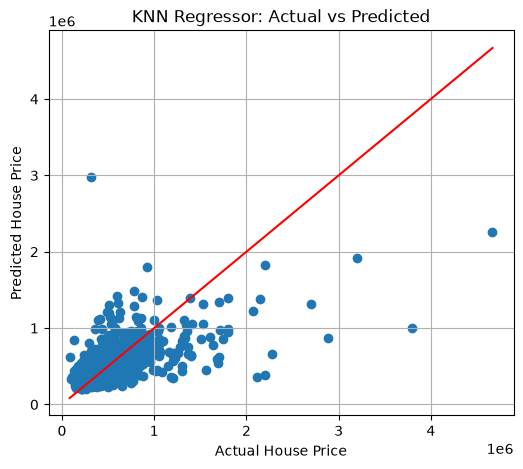

In [62]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, knn_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("KNN Regressor: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Support Vector Regressor

In [63]:
from sklearn.svm import SVR

### Create Model

In [64]:
svr_model = SVR(kernel="rbf")

### Train The Model

In [65]:
svr_model.fit(X_train, y_train)

print("SVR Model trained successfully!")

SVR Model trained successfully!


### Predict

In [66]:
svr_predictions = svr_model.predict(X_test)

### Evaluate

In [67]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("SVR Results")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

SVR Results
MAE : 232645.84837578223
MSE : 157258747937.54575
RMSE: 396558.6311474581
R² Score: -0.05705676518923197


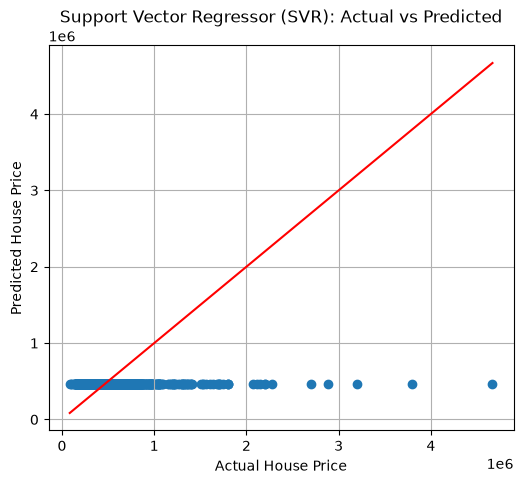

In [68]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, svr_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Support Vector Regressor (SVR): Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Comparison

In [69]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE": [mae, dt_mae, rf_mae, knn_mae, svr_mae],
    "RMSE": [rmse, dt_rmse, rf_rmse, knn_rmse, svr_rmse],
    "R² Score": [r2, dt_r2, rf_r2, knn_r2, svr_r2]
})

display(comparison)

,Algorithm,MAE,RMSE,R² Score
0,Linear Regression,"119,164.57","213,100.52",0.69
1,Decision Tree,"178,862.02","925,918.41",-4.76
2,Random Forest,"131,445.33","558,626.26",-1.10
3,KNN,"185,416.46","314,099.03",0.34
4,SVR,"232,645.85","396,558.63",-0.06


# Best Model Selection

In [70]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Algorithm    Linear Regression
MAE                 119,164.57
RMSE                213,100.52
R² Score                  0.69
Name: 0, dtype: object


# Cross Validation

In [72]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring="r2"
)


## Display The scores

In [73]:
print("Cross Validation Scores:")
print(cv_scores)

Cross Validation Scores:
[0.77195294 0.77066173 0.73614689 0.74418784 0.06692033]


In [74]:
print("Average CV Score:", cv_scores.mean())

Average CV Score: 0.6179739463481481


In [75]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.2758905470664587


# Advanced Model Evaluation

## Residual Analysis

In [76]:
residuals = y_test - predictions
print(residuals.head())

471    -84,065.08
2518   -67,299.73
23      23,831.32
3922    47,500.67
135    -32,592.65
Name: price, dtype: float64


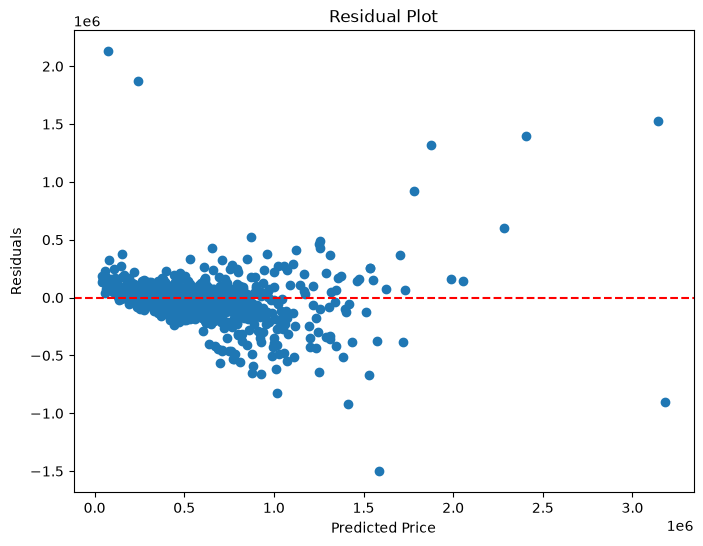

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Error Distribution

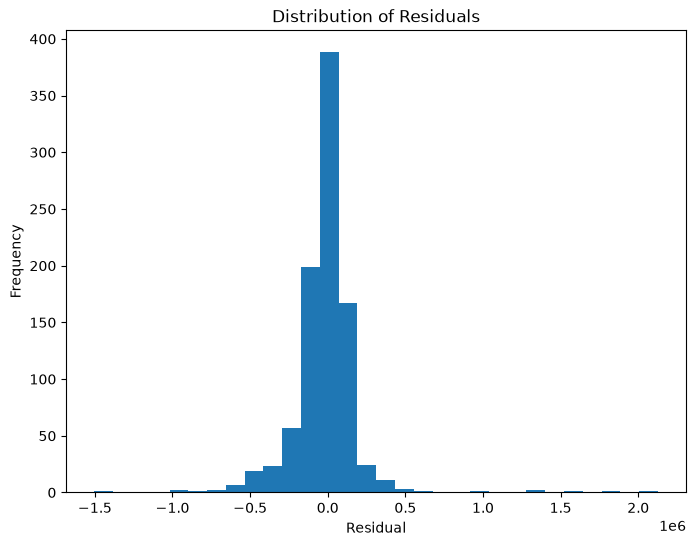

In [83]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Distribution of Residuals")

plt.show()

# Hyperparameter Tuning

### Decision Tree Hyperparameter Tuning

In [80]:
#Import Required Libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

#Create the Parameter Grid
param_grid = {
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

#Create the Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)

#Create GridSearchCV
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

#Train GridSearchCV
grid_search.fit(X_train, y_train)

#Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

#Best Score
print("Best Cross Validation Score:")
print(grid_search.best_score_)

#Best Model
best_dt = grid_search.best_estimator_

#Test the Tuned Model
dt_predictions = best_dt.predict(X_test)
print("R² Score:")
print(r2_score(y_test, dt_predictions))

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross Validation Score:
0.009730019405322098
R² Score:
-4.710534750140732


### Random Forest Hyperparameter Tuning

In [81]:
#Import Required Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

#Create the Parameter Grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

#Create the Model
rf_model = RandomForestRegressor(random_state=42)

#Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

#Train GridSearchCV
grid_search.fit(X_train, y_train)

#Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

#Best Score
print("Best Cross Validation Score:")
print(grid_search.best_score_)

#Best Model
best_rf = grid_search.best_estimator_

#Test the Tuned Model
rf_predictions = best_rf.predict(X_test)
print("R² Score:")
print(r2_score(y_test, rf_predictions))

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Score:
0.20911796759984994
R² Score:
-0.7725405987606957


# Model Optimization

## Comparison Table after  model tuning

In [82]:
import pandas as pd

optimization_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree (Original)",
        "Decision Tree (Tuned)",
        "Random Forest (Original)",
        "Random Forest (Tuned)",
        "KNN",
        "SVR"
    ],
    "R² Score": [
        0.69,
        -4.75,
        -4.71,
        -0.68,
        -0.77,
        0.32,
        -0.06
    ]
})

print(optimization_results)

                      Model  R² Score
0         Linear Regression      0.69
1  Decision Tree (Original)     -4.75
2     Decision Tree (Tuned)     -4.71
3  Random Forest (Original)     -0.68
4     Random Forest (Tuned)     -0.77
5                       KNN      0.32
6                       SVR     -0.06


In [84]:
print("Final Selected Model: Linear Regression")
print("Reason: Highest R² Score and most stable performance.")

Final Selected Model: Linear Regression
Reason: Highest R² Score and most stable performance.


## Save Best Model

In [86]:
import joblib

joblib.dump(model, "Best_House_Price_Model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [88]:
loaded_model = joblib.load("Best_House_Price_Model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


## Predict House Price for New Data

In [95]:
new_house = X.iloc[[0]]

predicted_price = loaded_model.predict(new_house)
print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

print("Actual Price: ₹{:,.2f}".format(y.iloc[0]))

Predicted House Price: ₹272,641.74
Actual Price: ₹313,000.00


In [98]:
new_house = X.iloc[[10]]

predicted_price = loaded_model.predict(new_house)
print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

print("Actual Price: ₹{:,.2f}".format(y.iloc[10]))

Predicted House Price: ₹420,532.94
Actual Price: ₹463,000.00
